In [1]:
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree
import yaml
import cartopy.crs as ccrs

import sys
sys.path.append("../src")
import energy_spectra as es

/leonardo_work/DestE_330_25/users/hschulz0/repos/mllam-exps-ShCu/analysis/../src/energy_spectra.py:258: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel(f"energy density / {unit}$^{2}\cdot$ m")


In [2]:
def combine_state_features(ds):
    """
    Combine individual state features from an xarray.Dataset into a single dataset.

    Parameters:
    ds (xarray.Dataset): The input dataset containing state features.

    Returns:
    xarray.Dataset: A new dataset with each state feature as a separate variable.
    """
    # Create a new dataset to hold the combined features
    combined_ds = xr.Dataset()

    # Loop through each state feature and add it to the combined dataset
    for feature in ds.state_feature.values:
        individual_array = ds.state.sel(state_feature=feature)
        combined_ds[feature] = individual_array

    return combined_ds

In [3]:
ds_interior = xr.open_dataset("../data/experiment/data/datastore.interior.domain03.zarr", engine="zarr")
creation_config_yaml = yaml.safe_load(ds_interior.attrs["creation_config"])
del ds_interior.attrs["creation_config"]
lats = np.rad2deg(ds_interior["clat"])
lons = np.rad2deg(ds_interior["clon"])
ds_interior = combine_state_features(ds_interior)

path_mllam = "../evals/rain_mse_boxcox_unroll100.zarr"
ds_mllam = xr.open_zarr(path_mllam, consolidated=False)
ds_mllam = combine_state_features(ds_mllam)

In [4]:
ds_mllam = ds_mllam.isel(elapsed_forecast_duration=[0, 1, 2, 3, 4, 5, 12, 72])
ds_interior = ds_interior.sel(time=slice(ds_mllam.start_time.min(), ds_mllam.start_time.max() + np.timedelta64(72, "h")))

In [5]:
ds_mllam

<xarray.Dataset> Size: 54GB
Dimensions:                    (elapsed_forecast_duration: 8,
                                grid_index: 524288, start_time: 643)
Coordinates:
  * elapsed_forecast_duration  (elapsed_forecast_duration) timedelta64[ns] 64B ...
  * grid_index                 (grid_index) int64 4MB 11255161 ... 3934314
  * start_time                 (start_time) datetime64[ns] 5kB 2020-02-12T00:...
    state_feature              <U13 52B 'u_10m'
    time                       (elapsed_forecast_duration) datetime64[ns] 64B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    u_10m                      (start_time, elapsed_forecast_duration, grid_index) float32 11GB dask.array<chunksize=(1, 1, 524288), meta=np.ndarray>
    v_10m                      (start_time, elapsed_forecast_duration, grid_index) float32 11GB dask.array<chunksize=(1, 1, 524288), meta=np.ndarray>
    tqc_dia                    (start_time, elapsed_forecast_duration, grid_index) float32 11GB dask.array<chunksize=(1, 1, 524288), meta=np.ndarray>
    t_2m                       (start_time, elapsed_forecast_duration, grid_index) float32 11GB dask.array<chunksize=(1, 1, 524288), meta=np.ndarray>
    rain_gsp_rate              (start_time, elapsed_forecast_duration, grid_index) float32 11GB dask.array<chunksize=(1, 1, 524288), meta=np.ndarray>

In [6]:
ds_interior

<xarray.Dataset> Size: 25GB
Dimensions:                       (grid_index: 524288, time: 1066)
Coordinates:
  * grid_index                    (grid_index) int64 4MB 11255161 ... 3934314
  * time                          (time) datetime64[ns] 9kB 2020-02-12T00:30:...
    clat                          (grid_index) float64 4MB 0.2515 ... 0.2392
    clon                          (grid_index) float64 4MB -0.9217 ... -0.9454
    state_feature                 <U13 52B 'u_10m'
    state_feature_long_name       <U48 192B ...
    state_feature_source_dataset  <U11 44B ...
    state_feature_units           <U10 40B ...
Data variables:
    u_10m                         (time, grid_index) float32 2GB ...
    v_10m                         (time, grid_index) float32 2GB ...
    qv_2m                         (time, grid_index) float32 2GB ...
    tqc_dia                       (time, grid_index) float32 2GB ...
    t_2m                          (time, grid_index) float32 2GB ...
    lhfl_s                        (time, grid_index) float32 2GB ...
    shfl_s                        (time, grid_index) float32 2GB ...
    rain_gsp_rate                 (time, grid_index) float32 2GB ...
    pres_sfc                      (time, grid_index) float32 2GB ...
    sob_t                         (time, grid_index) float32 2GB ...
    thb_t                         (time, grid_index) float32 2GB ...

In [7]:
import copy

def projection(projection_info):
    """Create a cartopy projection from a projection info dictionary.
    """
    class_name = projection_info["class_name"]
    ProjectionClass = getattr(ccrs, class_name)
    # need to copy otherwise we modify the dict stored in the dataclass
    # in-place
    kwargs = copy.deepcopy(projection_info["kwargs"])

    globe_kwargs = kwargs.pop("globe", {})
    if len(globe_kwargs) > 0:
        kwargs["globe"] = ccrs.Globe(**globe_kwargs)
    
    return ProjectionClass(**kwargs)

In [9]:
model_proj = projection(creation_config_yaml["extra"]["projection"])

# Extract unstructured grid coordinates
# Adjust these variable names if needed
grid_lat = np.rad2deg(ds_interior['clat'].isel(grid_index=slice(0,-1)).values)
grid_lon = np.rad2deg(ds_interior['clon'].isel(grid_index=slice(0,-1)).values)

xyz = model_proj.transform_points(
        ccrs.PlateCarree(), grid_lon, grid_lat
    )

# projected X, Y
# Stack coordinates for KDTree
grid_points = np.column_stack((xyz[:,0], xyz[:,1]))
center_pos = grid_points.mean(axis=0)

x = np.arange(center_pos[0]-60000, center_pos[0]+60000, 400)
y = np.arange(center_pos[1]-98000, center_pos[1]+98000, 400)
target_x, target_y = np.meshgrid(x, y)
target_points = np.column_stack((target_x.flatten(), target_y.flatten()))
# Build KDTree and query nearest neighbors
max_dist = 400  # example: meters, adjust as needed
tree = cKDTree(grid_points)
distances, idx = tree.query(target_points)

In [10]:
gt_regridded_data = {}
variables = ['t_2m',] # 'qv_2m', 'u_10m', 'v_10m', 'tqc_dia', 'pres_sfc']
for var in variables:
    data = ds_interior[var].isel(grid_index=idx).data.reshape(len(ds_interior.time), len(y), len(x))
    # Map data from unstructured grid to regular grid
    # regridded[distances.reshape(len(y), len(x), -1) > max_dist] = np.nan  # Mask out points beyond max_dist
    gt_regridded_data[var] = (["time", "y", "x"], data)

gt_regridded = xr.Dataset(
    gt_regridded_data,
    coords={"y": y, "x": x, "time": ds_interior.time.values}
)

print("Ground truth regridded")

mllam_regridded_data = {}
for var in variables:
    data = ds_mllam[var].isel(grid_index=idx).data.reshape(len(ds_mllam.start_time), len(ds_mllam.elapsed_forecast_duration), len(y), len(x))
    # Map data from unstructured grid to regular grid
    # regridded[distances.reshape(len(y), len(x), -1) > max_dist] = np.nan  # Mask out points beyond max_dist
    mllam_regridded_data[var] = (["start_time", "elapsed_forecast_duration", "y", "x"], data)
mllam_regridded = xr.Dataset(
    mllam_regridded_data,
    coords={"y": y, "x": x, "start": ds_mllam.start_time.values, "elapsed_forecast_duration": ds_mllam.elapsed_forecast_duration.values}
)


Ground truth regridded


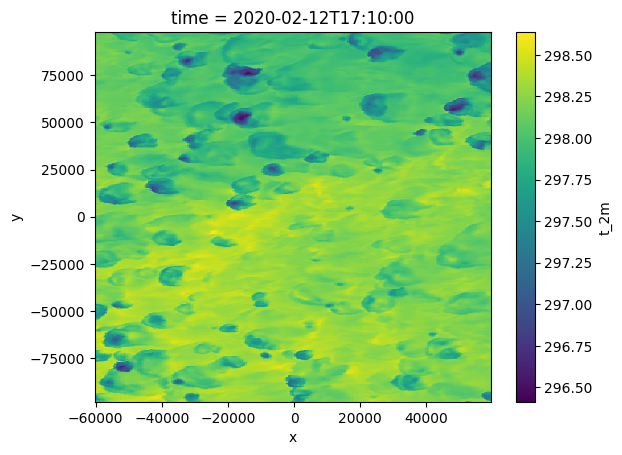

In [21]:
gt_regridded.t_2m.isel(time=100).plot()

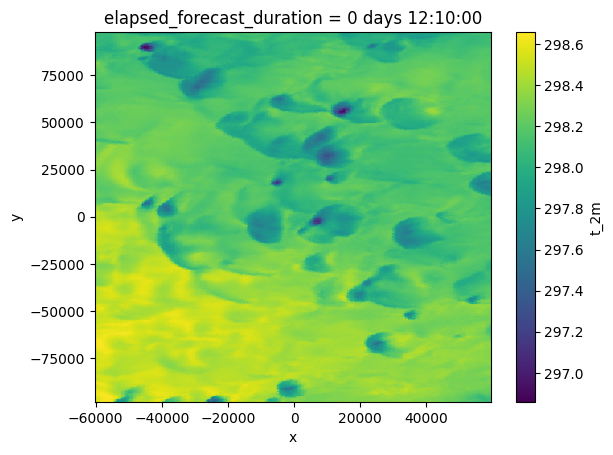

In [31]:
mllam_regridded.t_2m.isel(start_time=10, elapsed_forecast_duration=7).plot()

In [8]:
spectra_cache_npz = np.load("../spectra_cache.npz", allow_pickle=True)
spectra_cache = {key: spectra_cache_npz[key].item() for key in spectra_cache_npz.files}

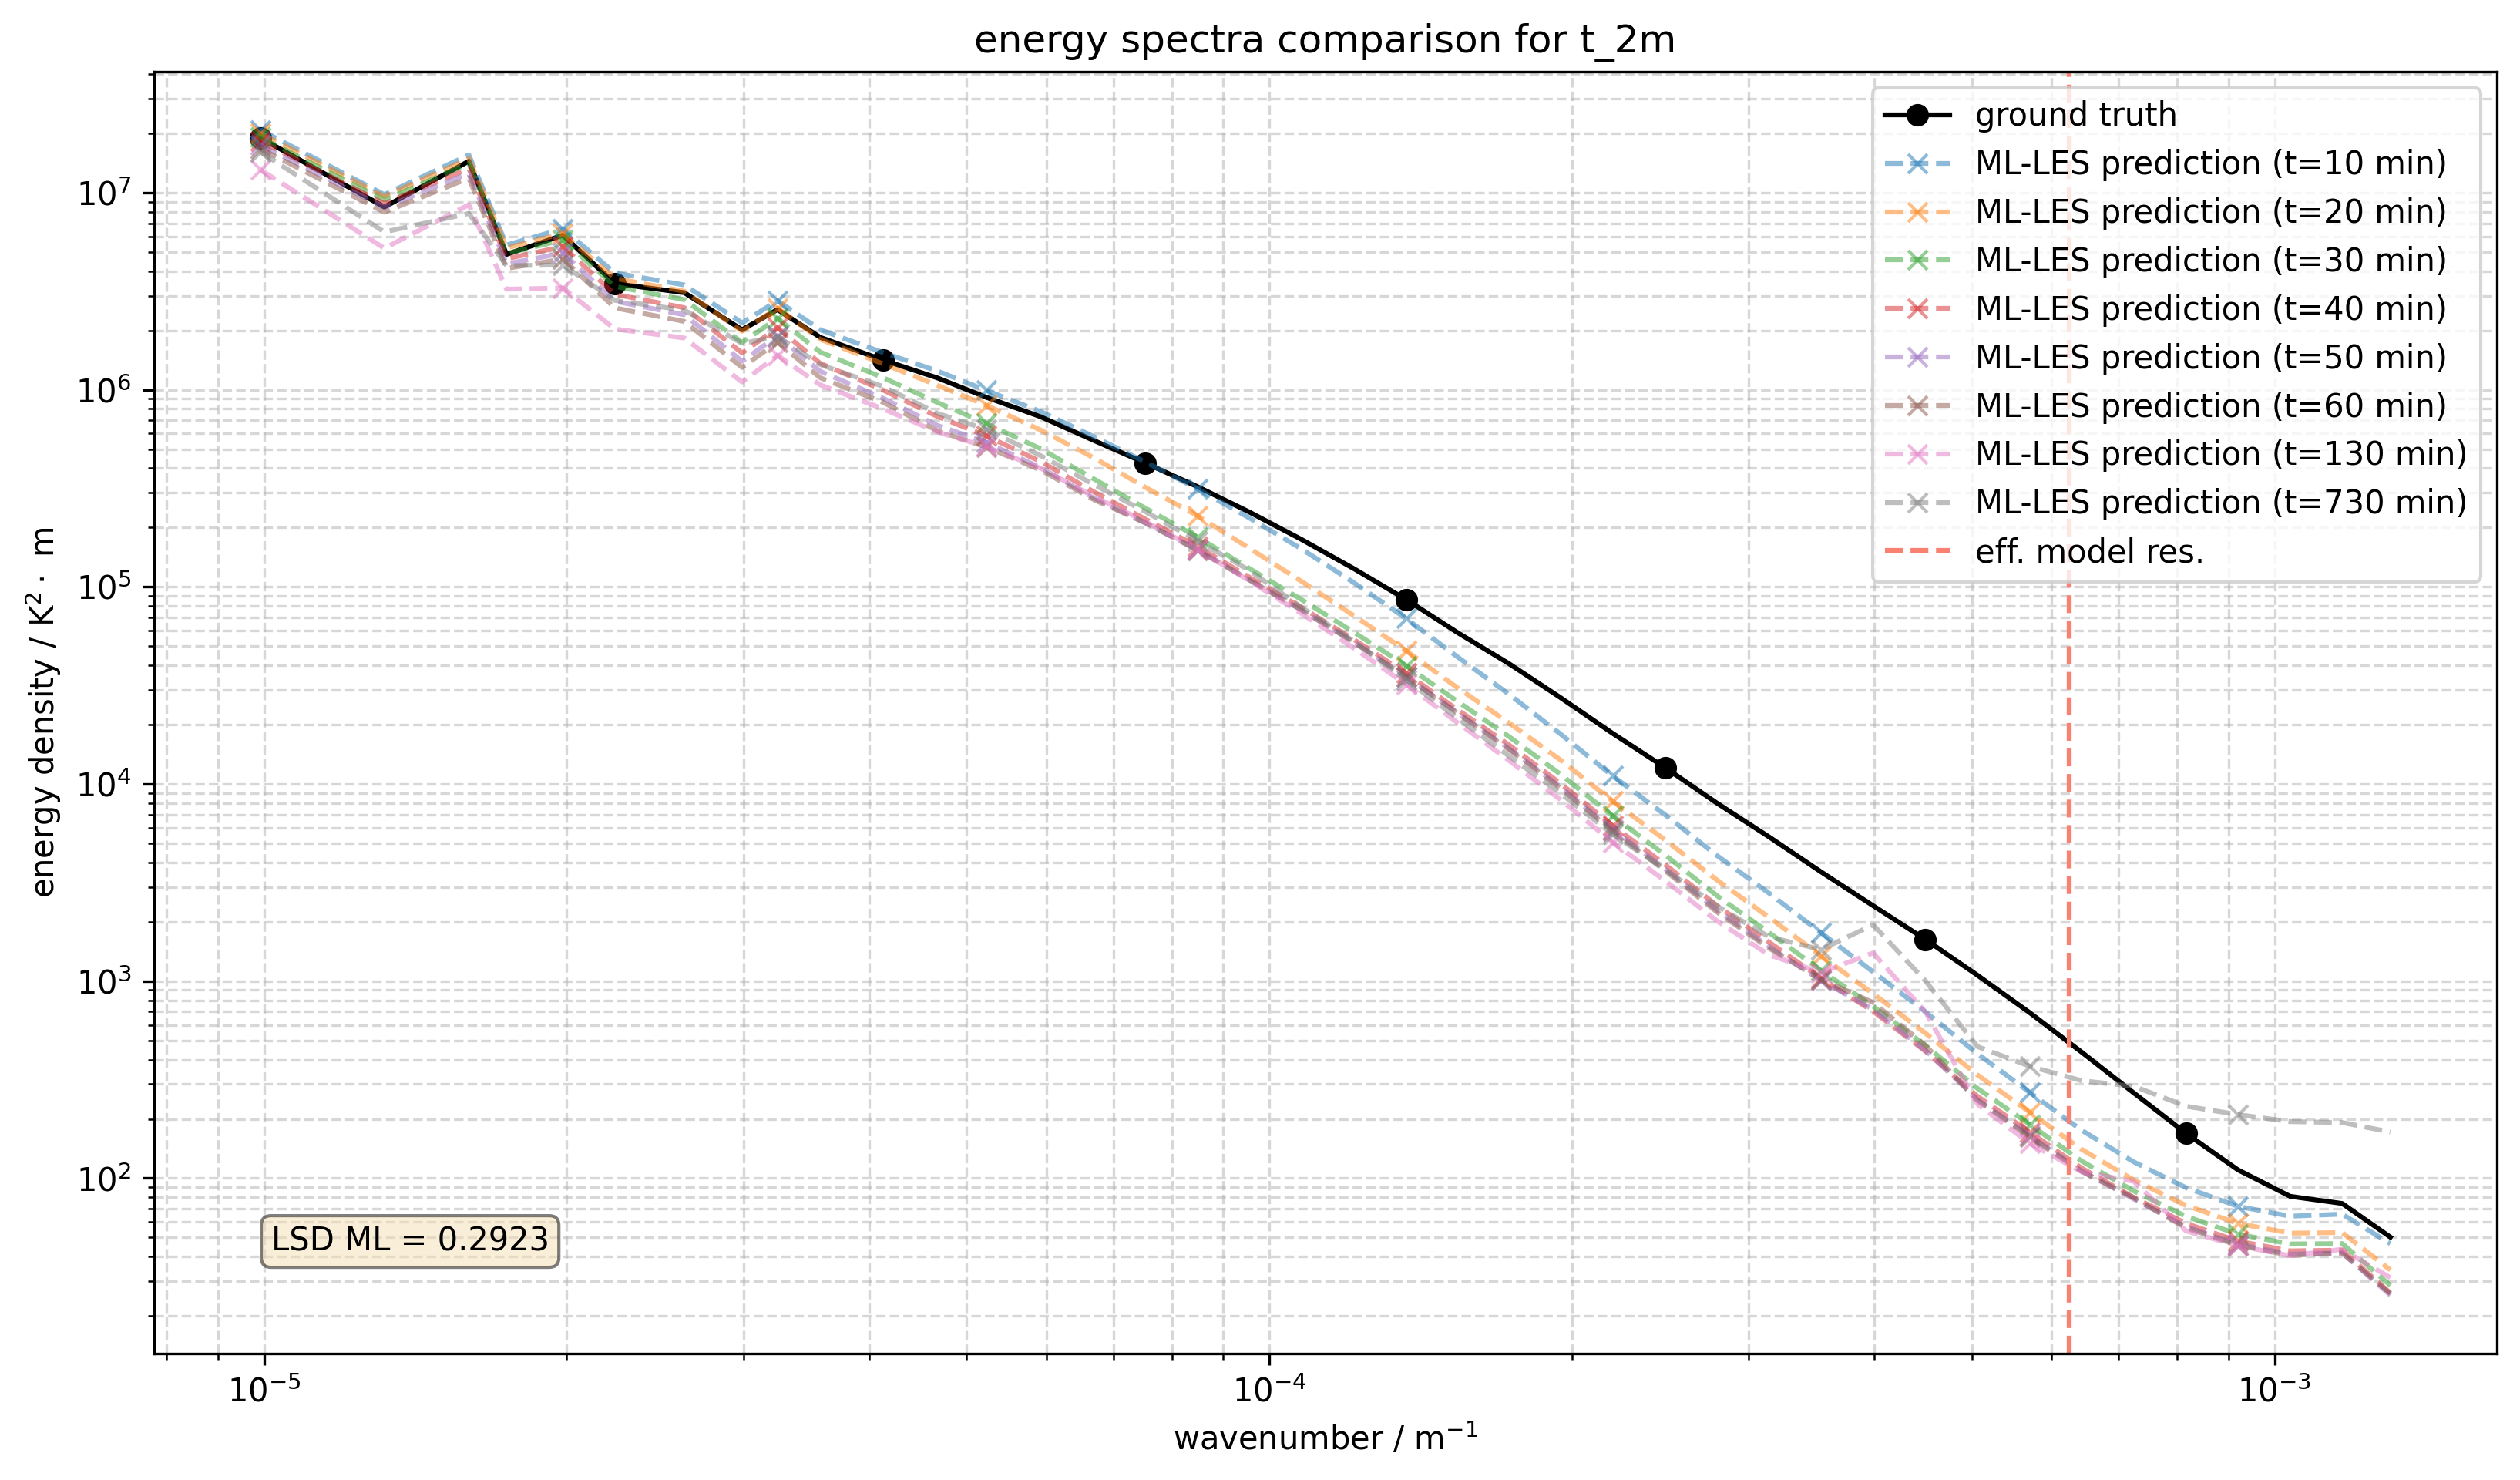

In [9]:
es.plot_energy_spectra(spectra_cache, "t_2m", show_legend=True, temporal=True)